In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("/content/ecommerce_customer_data_large.csv")

In [3]:
df.head(10)

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,03-05-2023 21:30,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,16-05-2021 13:57,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,13-07-2020 06:16,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,17-01-2023 13:14,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,01-05-2021 11:29,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0
5,13738,25-08-2022 06:48,Home,191,3,3722,Credit Card,27,1.0,Lauren Johnson,27,Female,0
6,13738,25-07-2023 05:17,Electronics,205,1,2773,Credit Card,27,NaN,Lauren Johnson,27,Female,0
7,13738,05-02-2023 19:31,Books,370,5,1486,Cash,27,1.0,Lauren Johnson,27,Female,0
8,13738,21-12-2021 03:29,Home,12,2,2175,Cash,27,NaN,Lauren Johnson,27,Female,0
9,13738,09-02-2023 00:53,Electronics,40,4,4327,Cash,27,0.0,Lauren Johnson,27,Female,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [5]:
LE = LabelEncoder()
df['Purchase Date'] = LE.fit_transform(df['Purchase Date'])
df['Product Category'] = LE.fit_transform(df['Product Category'])
df['Payment Method'] = LE.fit_transform(df['Payment Method'])
df['Customer Name'] = LE.fit_transform(df['Customer Name'])
df['Gender'] = LE.fit_transform(df['Gender'])

In [6]:
df.head(10)

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,19177,3,177,1,2427,2,31,1.0,18414,31,0,0
1,44605,119682,2,174,3,2448,2,31,1.0,18414,31,0,0
2,44605,97780,0,413,1,2345,1,31,1.0,18414,31,0,0
3,44605,124894,2,396,3,937,0,31,0.0,18414,31,0,0
4,44605,3018,0,259,4,2598,2,31,1.0,18414,31,0,0
5,13738,190680,3,191,3,3722,1,27,1.0,23331,27,0,0
6,13738,190160,2,205,1,2773,1,27,NaN,23331,27,0,0
7,13738,32605,0,370,5,1486,0,27,1.0,23331,27,0,0
8,13738,162114,3,12,2,2175,0,27,NaN,23331,27,0,0
9,13738,63713,2,40,4,4327,0,27,0.0,23331,27,0,0


In [7]:
SS = StandardScaler()
df['Customer ID'] = SS.fit_transform(df[['Customer ID']])
df['Purchase Date'] = SS.fit_transform(df[['Purchase Date']])
df['Total Purchase Amount'] = SS.fit_transform(df[['Total Purchase Amount']])
df['Customer Name'] = SS.fit_transform(df[['Customer Name']])

In [8]:
df.head(10)

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,1.359055,-1.449221,3,177,1,-0.206842,2,31,1.0,-0.133147,31,0,0
1,1.359055,0.035204,2,174,3,-0.192285,2,31,1.0,-0.133147,31,0,0
2,1.359055,-0.288281,0,413,1,-0.263685,1,31,1.0,-0.133147,31,0,0
3,1.359055,0.112183,2,396,3,-1.239719,0,31,0.0,-0.133147,31,0,0
4,1.359055,-1.687884,0,259,4,-0.088304,2,31,1.0,-0.133147,31,0,0
5,-0.782629,1.083820,3,191,3,0.690859,1,27,1.0,0.299170,27,0,0
6,-0.782629,1.076140,2,205,1,0.033007,1,27,NaN,0.299170,27,0,0
7,-0.782629,-1.250894,0,370,5,-0.859149,0,27,1.0,0.299170,27,0,0
8,-0.782629,0.661910,3,12,2,-0.381530,0,27,NaN,0.299170,27,0,0
9,-0.782629,-0.791439,2,40,4,1.110249,0,27,0.0,0.299170,27,0,0


In [9]:
df.describe()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
count,2.500000e+05,2.500000e+05,250000.000000,250000.000000,250000.000000,2.500000e+05,250000.000000,250000.000000,202618.000000,2.500000e+05,250000.000000,250000.000000,250000.00000
mean,1.091394e-17,-3.009859e-17,1.501868,254.742724,3.004936,-1.222702e-16,1.001716,43.798276,0.500824,7.923973e-17,43.798276,0.502704,0.20052
std,1.000002e+00,1.000002e+00,1.117280,141.738104,1.414737,1.000002e+00,0.815973,15.364915,0.500001,1.000002e+00,15.364915,0.499994,0.40039
min,-1.735761e+00,-1.732458e+00,0.000000,10.000000,1.000000,-1.819932e+00,0.000000,18.000000,0.000000,-1.752157e+00,18.000000,0.000000,0.00000
25%,-8.622823e-01,-8.662807e-01,1.000000,132.000000,2.000000,-8.660810e-01,0.000000,30.000000,0.000000,-8.702914e-01,30.000000,0.000000,0.00000
50%,-4.601629e-04,-4.871099e-04,2.000000,255.000000,3.000000,-2.670201e-04,1.000000,44.000000,1.000000,-1.190126e-02,44.000000,1.000000,0.00000
75%,8.620038e-01,8.658530e-01,3.000000,377.000000,4.000000,8.662401e-01,2.000000,57.000000,1.000000,8.532809e-01,57.000000,1.000000,0.00000
max,1.733384e+00,1.732784e+00,3.000000,500.000000,5.000000,1.819398e+00,2.000000,70.000000,1.000000,1.753940e+00,70.000000,1.000000,1.00000


In [10]:
df.shape

(250000, 13)

In [11]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [12]:
df['Returns'] = df['Returns'].fillna(df['Returns'].mean())

In [13]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,0
Customer Name,0


In [14]:
X_question = df.drop(columns='Customer ID',axis=1)
q_mean = X_question.mean()
total_mean = q_mean.mean()

In [15]:
X_question

,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,-1.449221,3,177,1,-0.206842,2,31,1.000000,-0.133147,31,0,0
1,0.035204,2,174,3,-0.192285,2,31,1.000000,-0.133147,31,0,0
2,-0.288281,0,413,1,-0.263685,1,31,1.000000,-0.133147,31,0,0
3,0.112183,2,396,3,-1.239719,0,31,0.000000,-0.133147,31,0,0
4,-1.687884,0,259,4,-0.088304,2,31,1.000000,-0.133147,31,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
249995,0.901001,3,436,1,0.650653,0,63,0.000000,-0.574695,63,1,0
249996,-1.331167,2,233,1,1.142829,1,66,1.000000,-1.415149,66,0,0
249997,-0.588799,2,441,5,1.781965,0,63,0.500824,0.366079,63,0,0
249998,1.287006,2,44,2,-0.144454,0,64,1.000000,0.590106,64,1,0


In [22]:
q_mean

,index,mean
0,Purchase Date,-3.009859e-17
1,Product Category,1.501868e+00
2,Product Price,2.547427e+02
3,Quantity,3.004936e+00
4,Total Purchase Amount,-1.222702e-16
5,Payment Method,1.001716e+00
6,Customer Age,4.379828e+01
7,Returns,5.008242e-01
8,Customer Name,7.923973e-17
9,Age,4.379828e+01


In [23]:
total_mean

np.float64(29.087653684256413)

In [25]:
q_mean.reset_index(level=0,inplace=True)

In [26]:
q_mean

,level_0,index,mean
0,0,Purchase Date,-3.009859e-17
1,1,Product Category,1.501868e+00
2,2,Product Price,2.547427e+02
3,3,Quantity,3.004936e+00
4,4,Total Purchase Amount,-1.222702e-16
5,5,Payment Method,1.001716e+00
6,6,Customer Age,4.379828e+01
7,7,Returns,5.008242e-01
8,8,Customer Name,7.923973e-17
9,9,Age,4.379828e+01


<Axes: xlabel='index', ylabel='mean'>

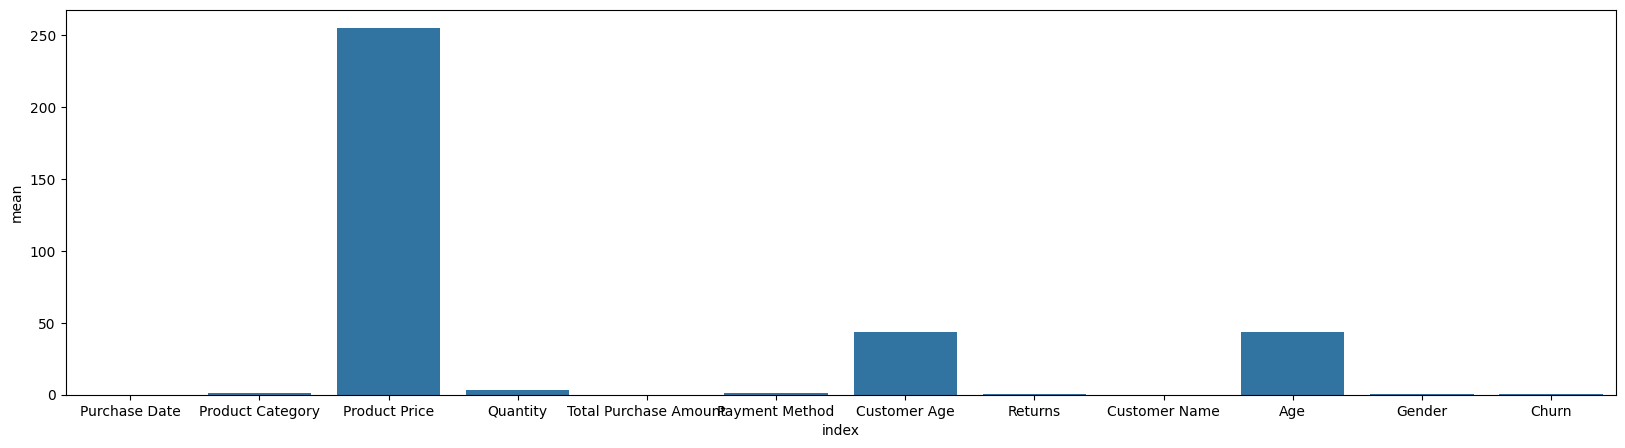

In [30]:
plt.figure(figsize=(20,5))
sns.barplot(x='index',y='mean',data = q_mean)

<Axes: >

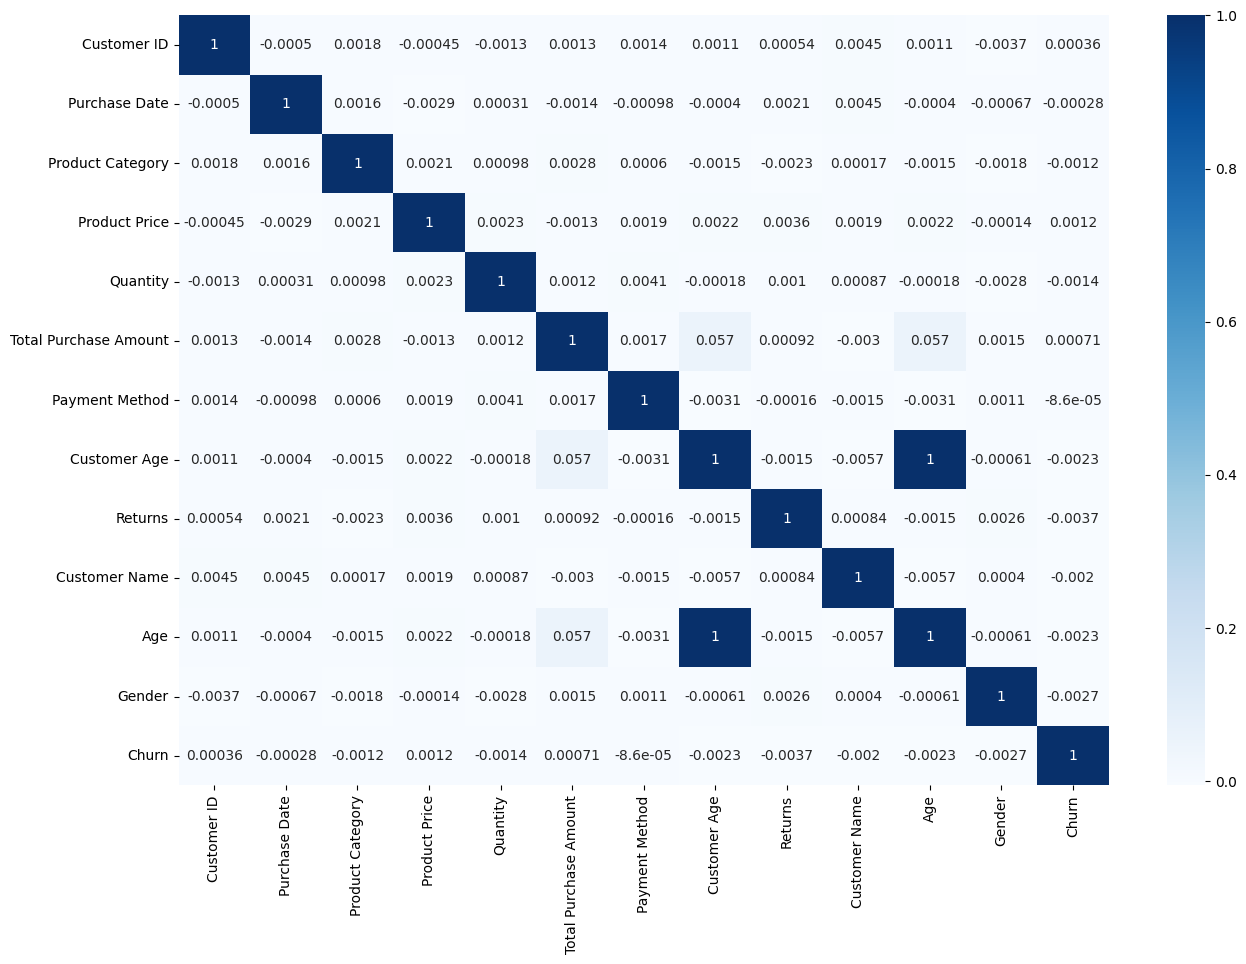

In [33]:
corr=df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr,annot = True,cmap='Blues')

In [37]:
X = df.drop(columns='Customer ID',axis=1)
pca = PCA(n_components=2,random_state=42)
X_pca = pca.fit_transform(X)

In [38]:
pca

PCA(n_components=2, random_state=42)

In [39]:
X_pca

array([[ -77.7489855 ,  -18.07310483],
       [ -80.74898558,  -18.07199525],
       [ 158.25091521,  -18.15493339],
       ...,
       [ 186.26674646,   27.09514503],
       [-210.73281975,   28.64221209],
       [  52.25152103,  -16.70133059]])

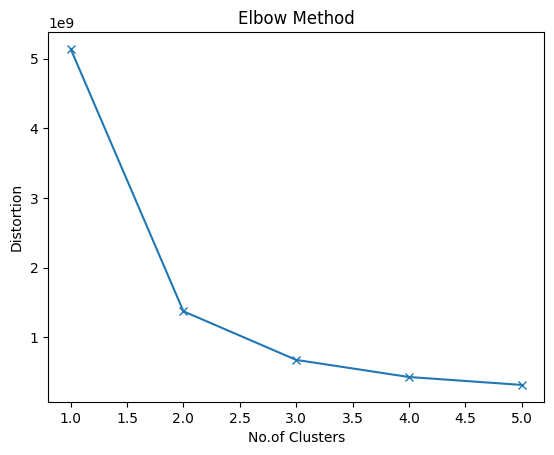

In [40]:
distortion = []
for i in range(1,6):
  km = KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
  km.fit(X_pca)
  distortion.append(km.inertia_)
plt.plot(range(1,6),distortion,marker='x')
plt.xlabel("No.of Clusters")
plt.ylabel("Distortion")
plt.title("Elbow Method")
plt.show()

In [41]:
model = KMeans(n_clusters=3,init='k-means++',random_state=42,n_init=10)
model.fit(X_pca)
y = model.predict(X_pca)

In [42]:
model

KMeans(n_clusters=3, n_init=10, random_state=42)

In [43]:
y

array([2, 1, 0, ..., 0, 1, 2], dtype=int32)

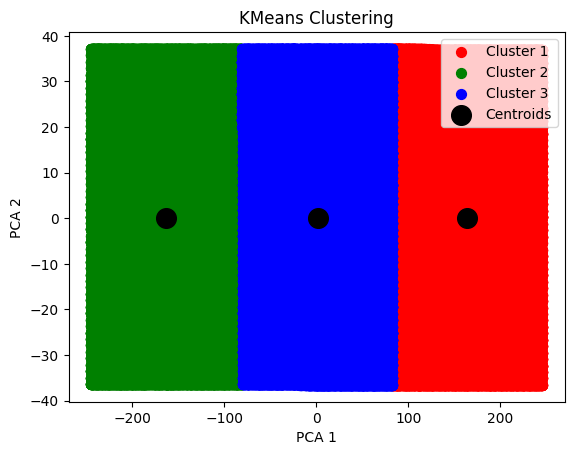

In [44]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red',label='Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='green',label='Cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=50,c='blue',label='Cluster 3')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=200,c='black',label='Centroids')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans Clustering")
plt.legend()
plt.show()